In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
np.random.seed(42)
torch.manual_seed(42)
X = np.arange(1, 501).reshape(-1, 1)   # 1,2,...,500
noise = np.random.normal(-0.1, 0.1, size=(500, 1))
y = 2 * X + 5 + noise

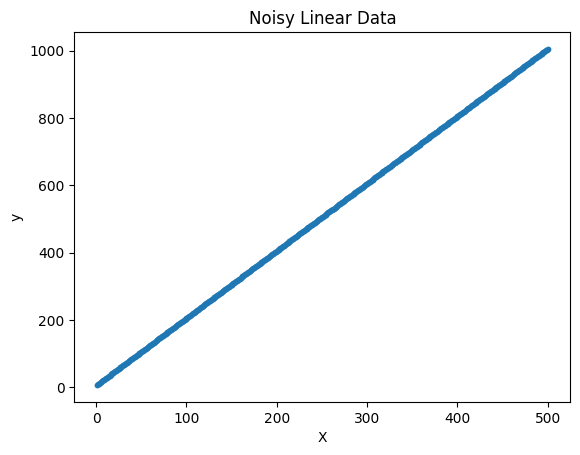

In [3]:
plt.figure()
plt.scatter(X, y, s=10)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Noisy Linear Data")
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [5]:
class NeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)

In [6]:
model = NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 500
losses = []

In [7]:
for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [100/500], Loss: 7.4566
Epoch [200/500], Loss: 3.7658
Epoch [300/500], Loss: 3.5881
Epoch [400/500], Loss: 3.3833
Epoch [500/500], Loss: 3.1594


In [8]:
model.eval()
with torch.no_grad():
    y_test_pred = model(X_test)
    test_mse = mean_squared_error(
        y_test.numpy(), y_test_pred.numpy()
    )

print("Test MSE:", test_mse)

Test MSE: 3.6996121406555176


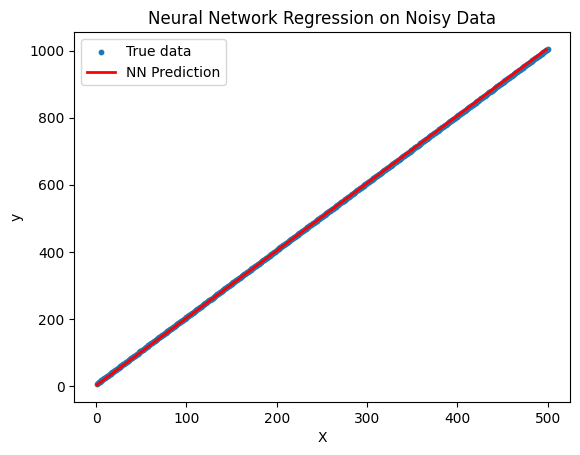

In [9]:
sorted_idx = X_test.squeeze().argsort()
X_sorted = X_test[sorted_idx]
y_sorted_pred = y_test_pred[sorted_idx]

plt.figure()
plt.scatter(X, y, s=10, label="True data")
plt.plot(X_sorted.numpy(), y_sorted_pred.numpy(), color="red", linewidth=2, label="NN Prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Neural Network Regression on Noisy Data")
plt.legend()
plt.show()